🏆 Seaborn Final Project — Titanic Dataset
Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("Titanic1.csv")
df.head()



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
import pandas as pd

df = pd.read_csv("Titanic1.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 15


In [7]:
import pandas as pd

df = pd.read_csv("Titanic1.csv")

print(df.columns)


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')


In [8]:
import pandas as pd

df = pd.read_csv("Titanic1.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 116.9 KB


In [9]:
import pandas as pd

df = pd.read_csv("Titanic1.csv")

df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
import pandas as pd

df = pd.read_csv("Titanic1.csv")

df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [14]:
import pandas as pd

df = pd.read_csv("Titanic1.csv")

age_mean = df["age"].mean()

print("Mean age:", age_mean)

df["age"]=df["age"].fillna(age_mean)
df["age"]

Mean age: 29.69911764705882


0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: age, Length: 891, dtype: float64

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

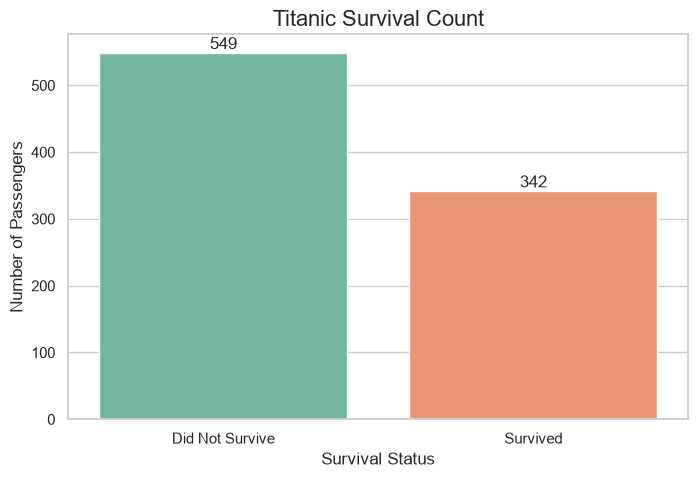

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="survived",
    hue="survived",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Titanic Survival Count",
    fontsize=16
)

plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.show()

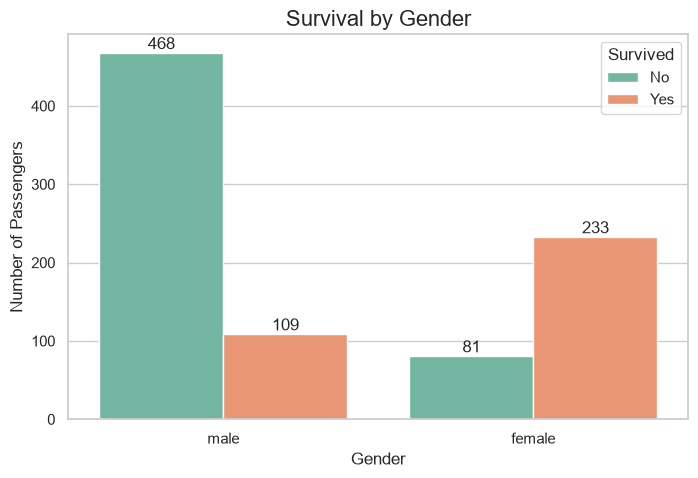

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="sex",
    hue="survived",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Survival by Gender",
    fontsize=16
)

plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

plt.show()

In [20]:
import pandas as pd

gender_survival = df.groupby("sex")["survived"].mean()

gender_survival = gender_survival * 100

print(gender_survival)

sex
female    74.203822
male      18.890815
Name: survived, dtype: float64


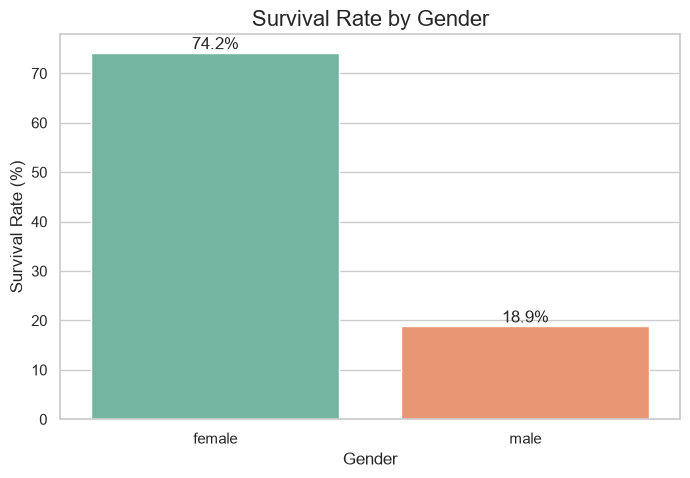

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

gender_survival = (
    df.groupby("sex")["survived"]
    .mean()
    .reset_index()
)

gender_survival["survived"] = (
    gender_survival["survived"] * 100
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=gender_survival,
    x="sex",
    y="survived",
    hue="sex",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.title(
    "Survival Rate by Gender",
    fontsize=16
)

plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")

plt.show()

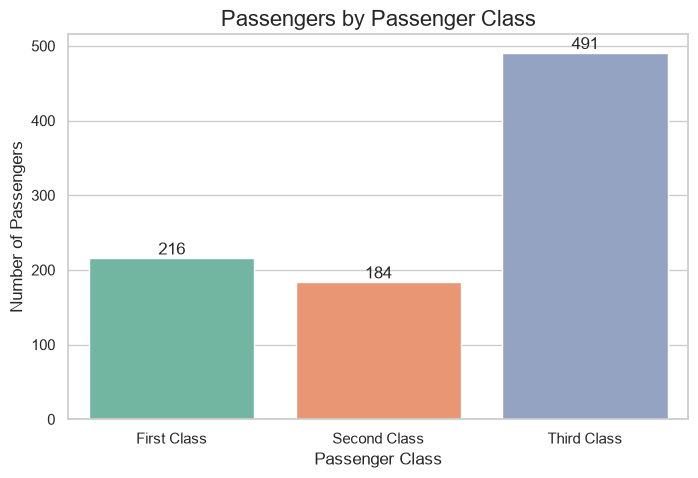

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="pclass",
    hue="pclass",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Passengers by Passenger Class",
    fontsize=16
)

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.xticks(
    [0, 1, 2],
    ["First Class", "Second Class", "Third Class"]
)

plt.show()

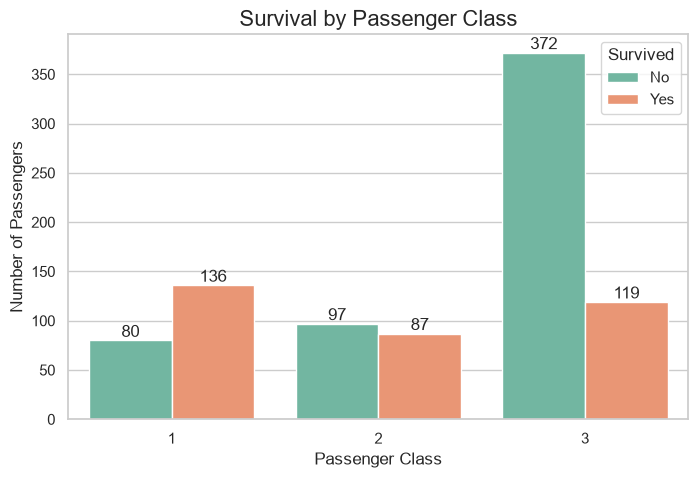

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="pclass",
    hue="survived",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Survival by Passenger Class",
    fontsize=16
)

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

plt.show()

In [24]:
import pandas as pd

class_survival = (
    df.groupby("pclass")["survived"]
    .mean()
    * 100
)

print(class_survival)

pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64


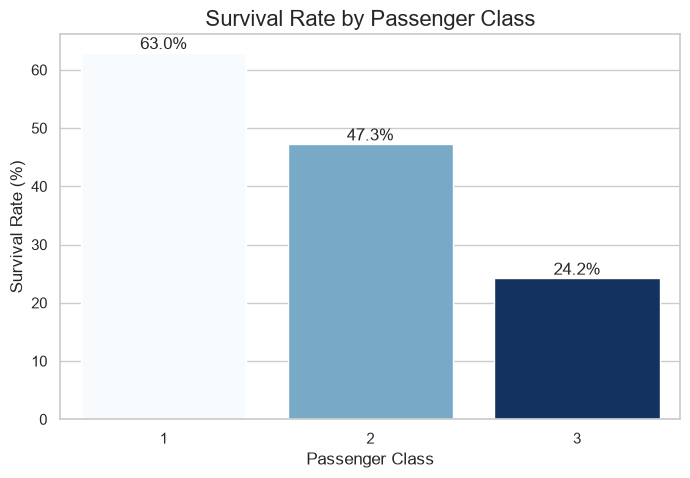

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

class_survival = (
    df.groupby("pclass")["survived"]
    .mean()
    .reset_index()
)

class_survival["survived"] *= 100

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=class_survival,
    x="pclass",
    y="survived",
    hue="pclass",
    palette="Blues",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.title(
    "Survival Rate by Passenger Class",
    fontsize=16
)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.show()

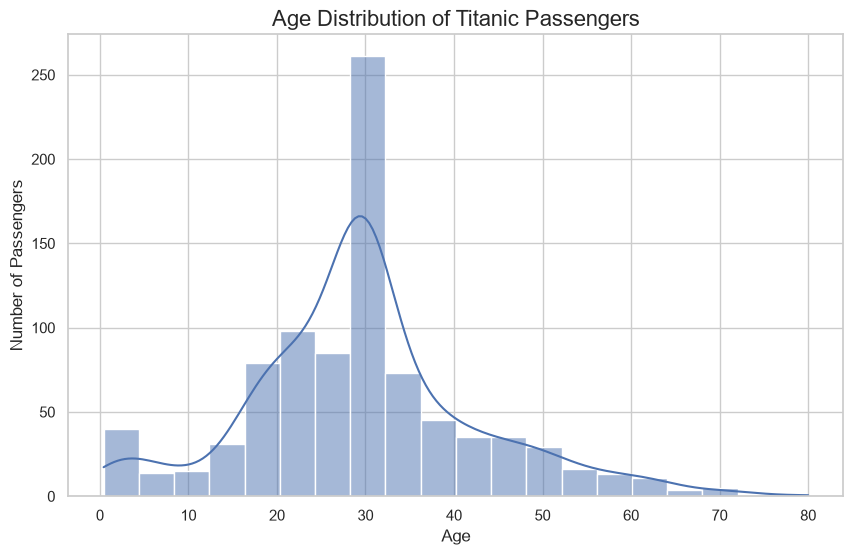

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title(
    "Age Distribution of Titanic Passengers",
    fontsize=16
)

plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

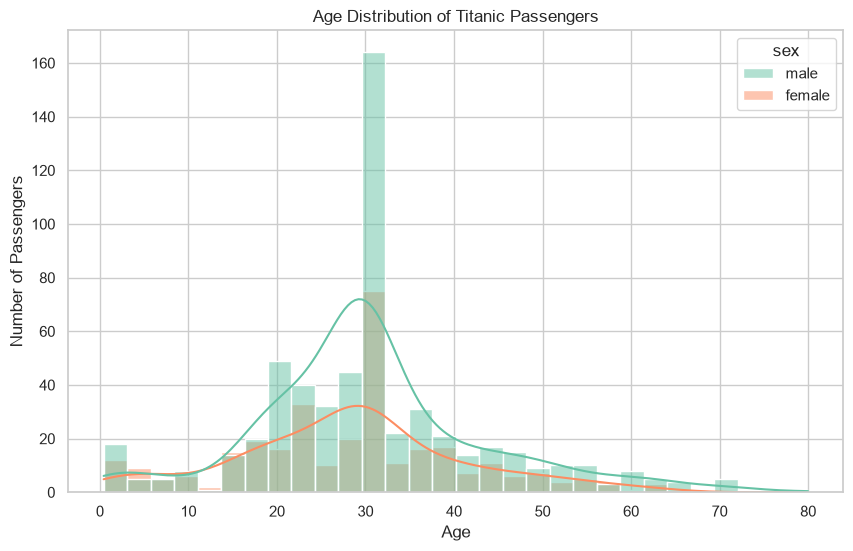

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))


sns.histplot(
    data=df,
    x="age",
    hue="sex",
    kde=True,
    palette="Set2"
)
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

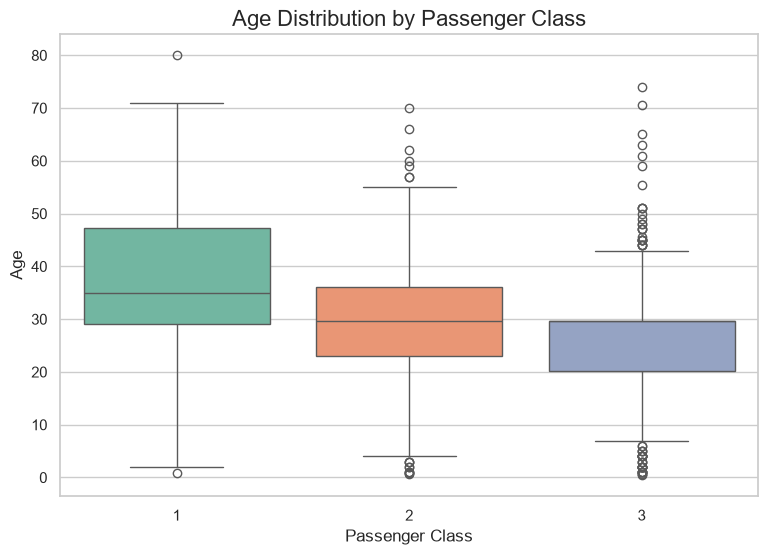

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="pclass",
    y="age",
    hue="pclass",
    palette="Set2",
    legend=False
)

plt.title(
    "Age Distribution by Passenger Class",
    fontsize=16
)

plt.xlabel("Passenger Class")
plt.ylabel("Age")

plt.show()

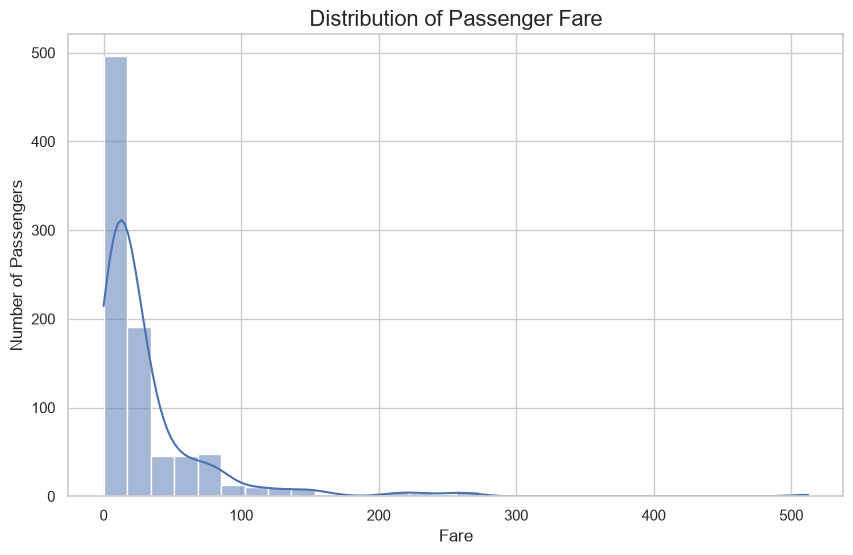

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="fare",
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Passenger Fare",
    fontsize=16
)

plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

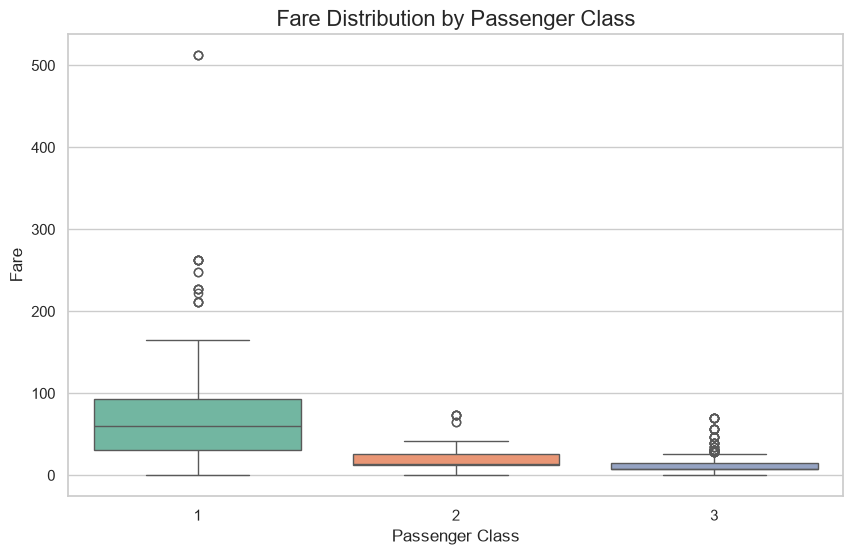

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="pclass",
    y="fare",
    hue="pclass",
    palette="Set2",
    legend=False
)

plt.title(
    "Fare Distribution by Passenger Class",
    fontsize=16
)

plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.show()

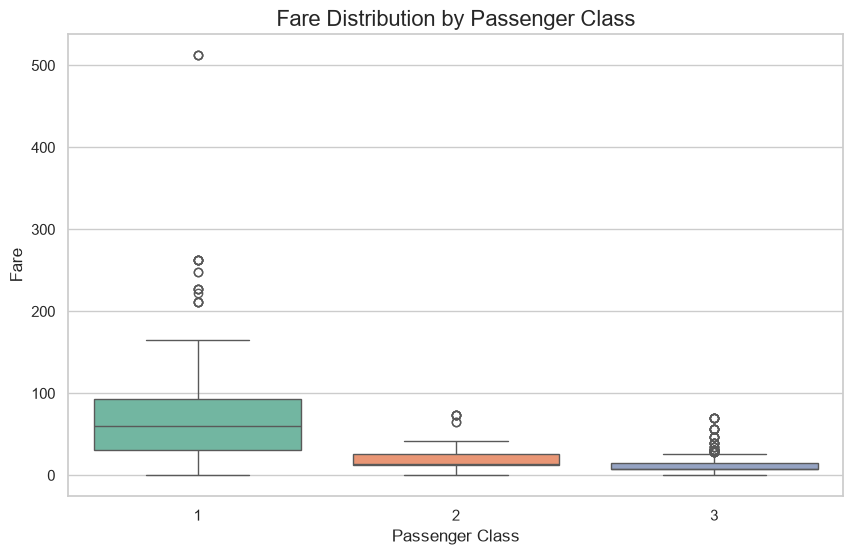

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="pclass",
    y="fare",
    hue="pclass",
    palette="Set2",
    legend=False
)

plt.title(
    "Fare Distribution by Passenger Class",
    fontsize=16
)

plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.show()

In [33]:
import pandas as pd

correlation = df[
    ["age", "fare", "pclass", "survived"]
].corr()

print(correlation)

               age      fare    pclass  survived
age       1.000000  0.091566 -0.331339 -0.069809
fare      0.091566  1.000000 -0.549500  0.257307
pclass   -0.331339 -0.549500  1.000000 -0.338481
survived -0.069809  0.257307 -0.338481  1.000000


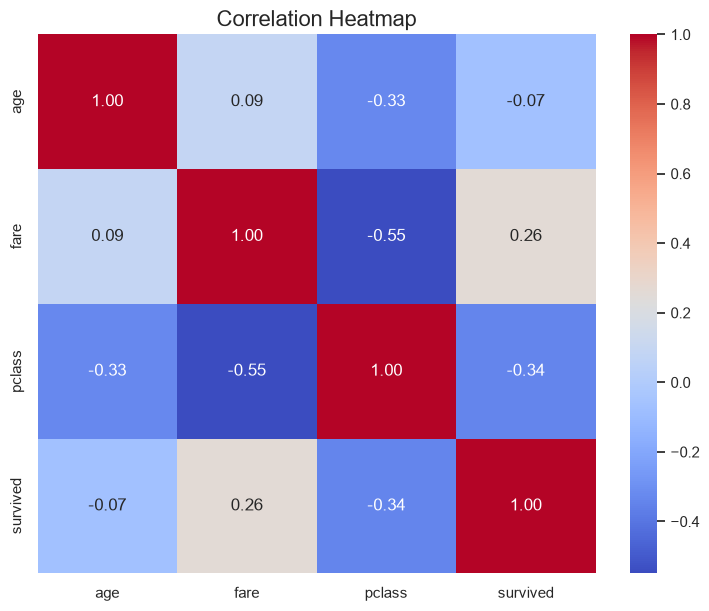

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df[
    ["age", "fare", "pclass", "survived"]
].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap",
    fontsize=16
)

plt.show()

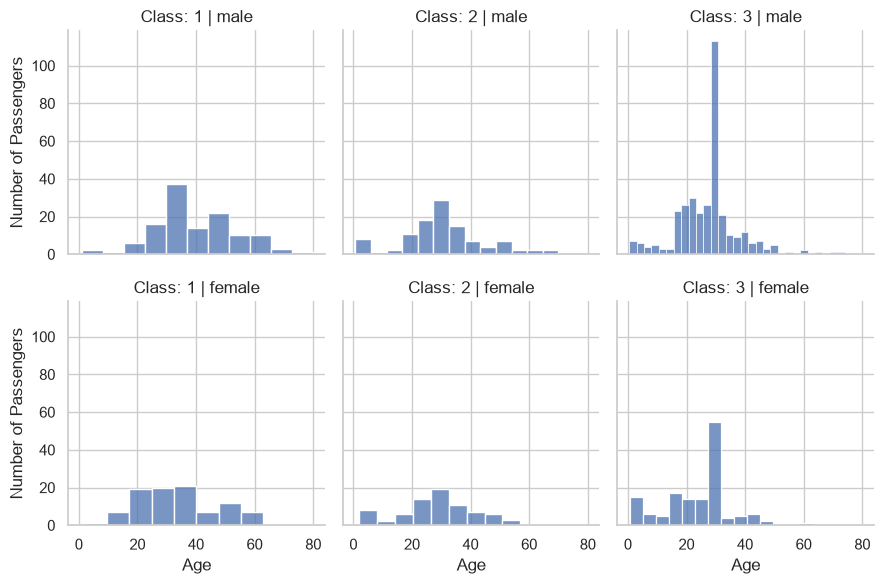

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    df,
    col="pclass",
    row="sex"
)

g.map(
    sns.histplot,
    "age"
)

g.set_axis_labels(
    "Age",
    "Number of Passengers"
)

g.set_titles(
    "Class: {col_name} | {row_name}"
)

plt.show()

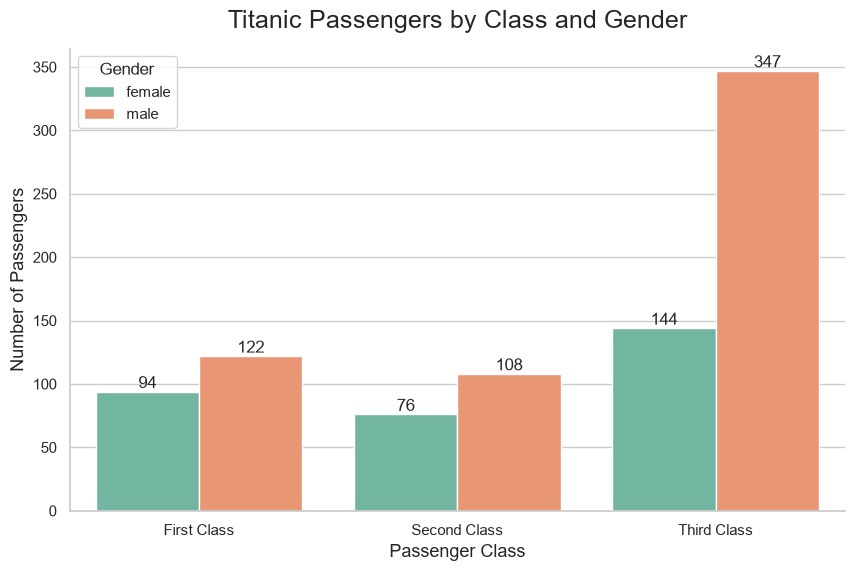

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x="pclass",
    hue="sex",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Titanic Passengers by Class and Gender",
    fontsize=18,
    pad=15
)

plt.xlabel(
    "Passenger Class",
    fontsize=13
)

plt.ylabel(
    "Number of Passengers",
    fontsize=13
)

plt.xticks(
    [0, 1, 2],
    ["First Class", "Second Class", "Third Class"]
)

plt.legend(
    title="Gender"
)

sns.despine()

plt.show()